# **SECTION 1**

**Question 1:**


```
1. Convert the RGB image to grayscale using the standard luminance formula:
I=0.299R+0.587G+0.114B
2. Downscale the grayscale image by a factor of 0.5 (i.e., reduce both rows and columns by half) using nearest neighbor interpolation.
3. Upscale the downscaled image back to its original size using bilinear interpolation (your own implementation).
4. Perform the same upscaling using OpenCV’s built-in function:
5. Compare your bilinear interpolation result with OpenCV’s result.
6. Compute and report the following error metrics:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
```



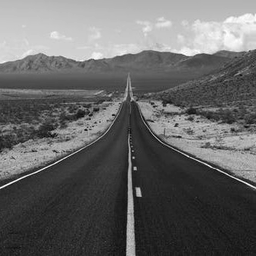

(256, 256)


In [ ]:
#import the libraries
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import cv2
#reading the image
image = cv2.imread('/content/road.bmp')

# Convert to grayscale image
(b,g,r)=cv2.split(image)
h=image.shape[0]
w=image.shape[1]
image_gray=np.zeros((h,w))
for i in range(h):
  for j in range(w):
    image_gray[i][j]=0.299*b[i][j]+0.587*g[i][j]+0.114*r[i][j]

# show the image
cv2_imshow(image_gray)
print(image_gray.shape)

(256, 256)


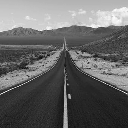

(128, 128)


In [ ]:
#DownScale the grayscale image

def Nearest_Neighbor_Interpolation(image,height,width):
  H_in=image.shape[0]
  W_in=image.shape[1]
  resize_image=np.zeros((height,width))
  # if height%H_in!=0 or width%W_in!=0:
  #   return resize_image

  factor1=height/H_in
  factor2=width/W_in
  for i in range(height):
    for j in range(width):
      resize_image[i,j]=image[int(i/factor1),int(j/factor2)]

  return resize_image

h=image_gray.shape[0]
w=image_gray.shape[1]
new_image=Nearest_Neighbor_Interpolation(image_gray,int(h/2),int(w/2))
print(image_gray.shape)
cv2_imshow(new_image)
print(new_image.shape)

In [ ]:
#upscale using Manual Bilinear interpolation
import numpy as np
import cv2

def bilinear_resize_manual(your_image, new_h, new_w):
  H_in=your_image.shape[0]
  W_in=your_image.shape[1]
  output=np.zeros((new_h,new_w))

  for i in range(new_h):
    for j in range(new_w):

      # step-01:
      x=(j+0.5)*(W_in/new_w)-0.5
      y=(i+0.5)*(H_in/new_h)-0.5

      # step-02:
      x0=int(np.floor(x))
      y0=int(np.floor(y))

      x1=min(x0+1,W_in-1)
      y1=min(y0+1,H_in-1)

      # step-03:
      x0=max(x0,0)
      y0=max(y0,0)

      #step-04:
      dx=x-x0
      dy=y-y0

      #step-05:
      A=image_gray[y0, x0]
      B=image_gray[y0, x1]
      C=image_gray[y1, x0]
      D=image_gray[y1, x1]

      #step-06:
      Top=A*(1-dx)+(B*dx)
      Bottom=C*(1-dx)+(D*dx)
      value=Top*(1-dy)+Bottom*dy
      output[i,j]=value

  return output.astype(your_image.dtype)

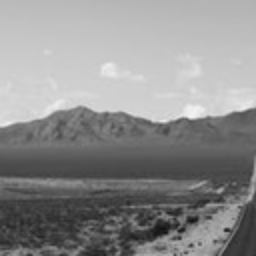

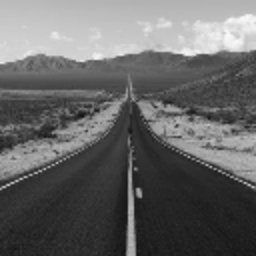

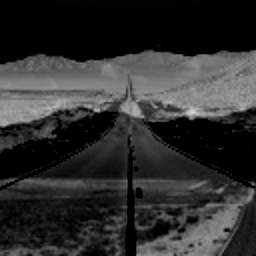

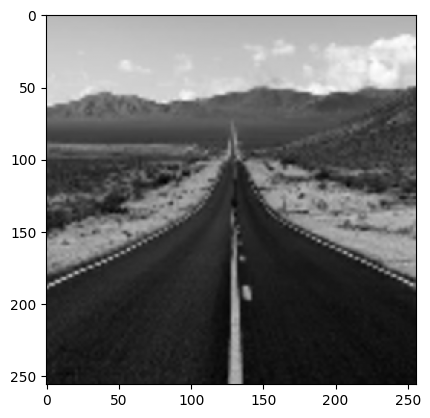

In [ ]:
#Compare your result with builtin function
manual_out1 = bilinear_resize_manual(new_image,256,256)
cv2_imshow(manual_out1)
plt.imshow(manual_out1, cmap='gray')

cv2_out1 = cv2.resize(new_image,(256,256) , interpolation=cv2.INTER_LINEAR)
cv2_imshow(cv2_out1)
plt.imshow(cv2_out1,cmap='gray')

diff = manual_out1 - cv2_out1

cv2_imshow(diff)

# **SECTION 2**

 Q1. Implement gamma correction transformation

In [ ]:
def gamma_correction(image, gamma, c=1.0):
    """
    Apply power law transformation

    Parameters:
    image: Input image
    gamma: Gamma value
    c: Scaling constant (usually 1.0)

    Returns:
    Gamma-corrected image
    """

    # Normalize image to 0-1 range
    img_normalized = image/255

    # Apply gamma correction
    corrected = c*(img_normalized**gamma)*255

    # Scale back to 0-255
    corrected = (corrected * 255).astype(np.uint8)

    return corrected


# Alternative using lookup table (faster for multiple pixels)
def gamma_correction_lut(image, gamma):
    """
    Gamma correction using lookup table for efficiency
    """
    # Create lookup table
    inv_gamma = 1/gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype(np.uint8)

    # Apply lookup table
    corrected = (table * 255).astype(np.uint8)

    return corrected


# Test gamma correction
gray = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)
gamma_1 = gamma_correction(gray, 0.4)      # Brighten (gamma < 1)
gamma_2 = gamma_correction(gray, 2.5)      # Darken (gamma > 1)
gamma_3 = gamma_correction_lut(gray, 1.0)  # No change

Q2. Implement logarithmic transformation

In [ ]:
def log_transformation(image, c=1.0):
    """
    Apply logarithmic transformation
    Useful for expanding dark regions

    Parameters:
    image: Input image
    c: Scaling constant

    Returns:
    Log-transformed image
    """

    # Convert to float
    img_float = image.astype(np.float32)

    # Apply logarithmic transformation
    log_img = c * np.log2(1+img_float)

    # Normalize to 0-255
    log_img = (log_img / log_img.max()) * 255

    return log_img.astype(np.uint8)


def inverse_log_transformation(image, c=1.0):
    """
    Apply inverse logarithmic transformation
    s = (e^(r/c)) - 1
    Opposite of log transformation
    """

    # Normalize image to 0-1
    img_normalized = image/255

    # Apply inverse log
    inv_log = 2**(img_normalized/c)-1

    # Scale to 0-255
    inv_log = (inv_log / inv_log.max()) * 255

    return inv_log.astype(np.uint8)


# Test logarithmic transformations
gray = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)
log_img = log_transformation(gray, c=50)
inv_log_img = inverse_log_transformation(gray, c=50)

Q3. Implement histogram equalization to improve image contrast.

In [ ]:
def histogram_equalization(image):
    """
    Apply histogram equalization
    Formula: s_k = (L-1) * Σ(p_r(i)) for i = 0 to k
    where p_r is probability (normalized histogram)

    Parameters:
    image: Grayscale image

    Returns:
    Equalized image
    """

    height, width = image.shape[0],image.shape[1]
    total_pixels = height*width

    # Step 1: Compute histogram
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()

    # Step 2: Compute normalized histogram (PDF)
    pdf = histogram / total_pixels

    # Step 3: Compute CDF (cumulative distribution function)
    cdf = np.cumsum(pdf)  # Cumulative sum of PDF

    # Step 4: Create mapping function s = (L-1) * CDF
    L = 256
    mapping = (cdf * (L - 1)).astype(np.uint8)

    # Step 5: Apply mapping to all pixels
    equalized = cv2.LUT(image, mapping)  # Use cv2.LUT

    return equalized


def histogram_equalization_opencv(image):
    """
    Histogram equalization using OpenCV function
    """
    return cv2.equalizeHist(image)


# Test histogram equalization
gray = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)
equalized_manual = histogram_equalization(gray)
equalized_opencv = histogram_equalization_opencv(gray)

# For color images - equalize each channel
def histogram_equalization_color(image):
    # Convert BGR to HSV (better for color images)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Equalize V channel
    hsv[:,:,2] = cv2.equalizeHist(hsv[:,:,2])

    # Convert back to BGR
    result = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return result

Q4. Implement a custom piecewise linear transformation with control points.

In [ ]:
def piecewise_linear_transformation(image, control_points):
    """
    Apply piecewise linear transformation using control points

    Parameters:
    image: Input image
    control_points: List of (x, y) tuples defining the transformation curve
                   e.g., [(0, 0), (50, 80), (150, 100), (255, 255)]

    Returns:
    Transformed image
    """

    # Create lookup table (256 values for 8-bit image)
    lut = np.zeros(256, dtype=np.uint8)

    # Sort control points by x coordinate
    sorted_points = sorted(control_points, key=lambda p: p[0])

    # Fill lookup table using linear interpolation
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i+1]

        # Calculate slope
        if x2 - x1 == 0:
            slope = 0
        else:
            slope = (y2 - y1) / (x2 - x1)

        # Fill values between x1 and x2
        for x in range(int(x1), int(x2) + 1):
            lut[x] = int(y1 + slope * (x - x1))

    # Apply lookup table to image
    if len(image.shape) == 2:  # Grayscale
        result = cv2.LUT(image, lut)
    else:  # Color image
        # For color images, apply the LUT to each channel separately
        result = cv2.merge([
            cv2.LUT(image[:,:,0], lut),
            cv2.LUT(image[:,:,1], lut),
            cv2.LUT(image[:,:,2], lut)
        ])

    return result


# Test with different control point configurations
gray = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)

# Contrast stretching curve
points1 = [(0, 0), (64, 32), (192, 224), (255, 255)]
contrast = piecewise_linear_transformation(gray, points1)

# S-curve (sigmoid-like)
points2 = [(0, 0), (85, 50), (170, 200), (255, 255)]
s_curve = piecewise_linear_transformation(gray, points2)

# Inverse S-curve
points3 = [(0, 0), (85, 150), (170, 100), (255, 255)]
inv_s_curve = piecewise_linear_transformation(gray, points3)

# **---------------------------THE END----------------------**